<a href="https://colab.research.google.com/github/TranNguyenMinhQuan/Repo2/blob/main/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def load_data(path):
    df = pd.read_csv(path)
    return df

df = load_data("titanic_disaster.csv")
print(df.head(10))


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


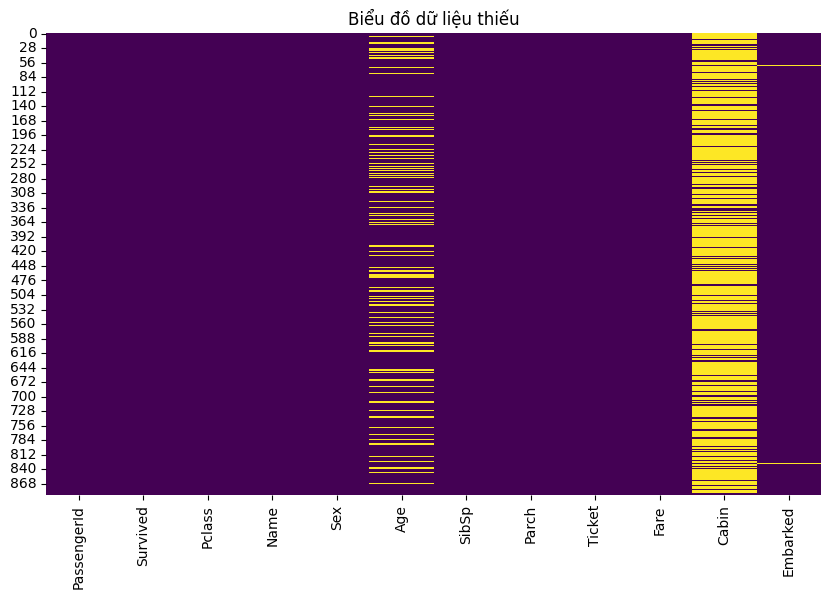

In [5]:
print(df.isnull().sum())
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Biểu đồ dữ liệu thiếu")
plt.show()


In [14]:

if 'Name' in df.columns:
    df[['secondName','firstName']] = df['Name'].str.split(',', n=1, expand=True)
    df.drop('Name', axis=1, inplace=True)
    print("Đã tách cột Name thành secondName và firstName, sau đó xoá Name.")
elif 'secondName' not in df.columns or 'firstName' not in df.columns:
    temp = pd.read_csv("titanic_disaster.csv")
    df['Name'] = temp['Name']
    df[['secondName','firstName']] = df['Name'].str.split(',', n=1, expand=True)
    df.drop('Name', axis=1, inplace=True)
    print("Đã nạp lại cột Name từ file gốc và tách lại thành secondName, firstName.")
else:
    print("Đã tách secondName và firstName")

print(df[['secondName','firstName']].head(10))


Đã tách secondName và firstName
  secondName                                    firstName
0     Braund                              Mr. Owen Harris
1    Cumings   Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                  Miss. Laina
3   Futrelle           Mrs. Jacques Heath (Lily May Peel)
4      Allen                            Mr. William Henry
5      Moran                                    Mr. James
6   McCarthy                                Mr. Timothy J
7    Palsson                        Master. Gosta Leonard
8    Johnson     Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9     Nasser                  Mrs. Nicholas (Adele Achem)


In [16]:
df['Sex'] = df['Sex'].replace({'male':'M','female':'F'})
print(df[['Sex']].head(10))


  Sex
0   M
1   F
2   F
3   F
4   M
5   M
6   M
7   M
8   F
9   F


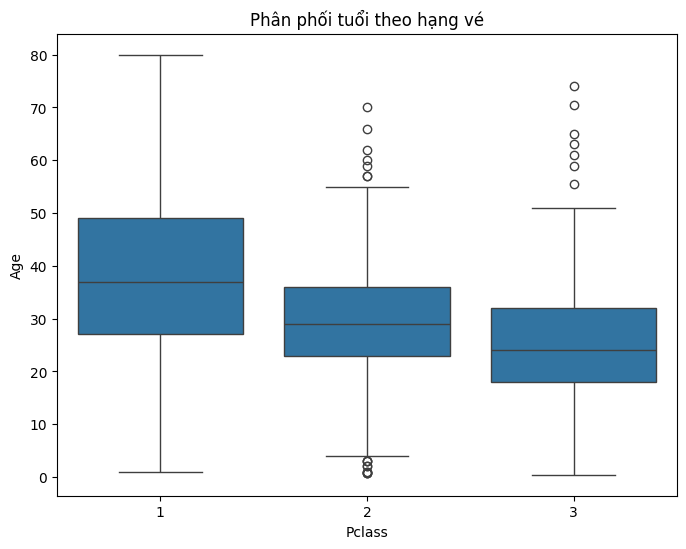

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title("Phân phối tuổi theo hạng vé")
plt.show()


   Pclass   Age
0       3  22.0
1       1  38.0
2       3  26.0
3       1  35.0
4       3  35.0
5       3  24.0
6       1  54.0
7       3   2.0
8       3  27.0
9       2  14.0


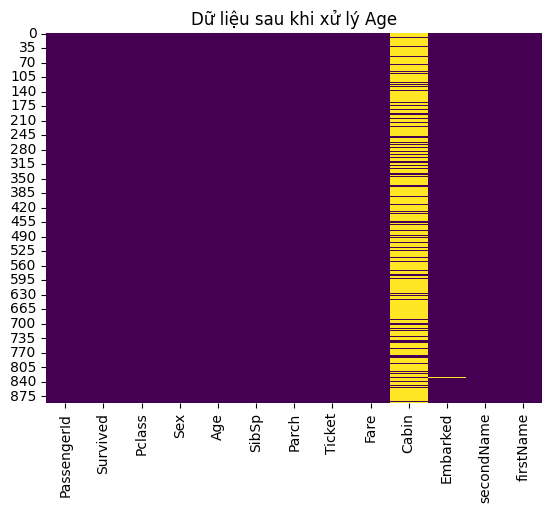

In [18]:
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))
print(df[['Pclass','Age']].head(10))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Dữ liệu sau khi xử lý Age")
plt.show()


In [19]:
def age_group(age):
    if age <= 12: return 'Kid'
    elif age <= 18: return 'Teen'
    elif age <= 60: return 'Adult'
    else: return 'Older'

df['AgeGroup'] = df['Age'].apply(age_group)
print(df[['Age','AgeGroup']].head(10))


    Age AgeGroup
0  22.0    Adult
1  38.0    Adult
2  26.0    Adult
3  35.0    Adult
4  35.0    Adult
5  24.0    Adult
6  54.0    Adult
7   2.0      Kid
8  27.0    Adult
9  14.0     Teen


In [20]:
if 'firstName' in df.columns:
    df['namePrefix'] = df['firstName'].str.extract(r' ([A-Za-z]+)\.')
    print(df[['secondName','firstName','namePrefix']].head(10))
else:
    print("Không có cột firstName để tách danh xưng.")


  secondName                                    firstName namePrefix
0     Braund                              Mr. Owen Harris         Mr
1    Cumings   Mrs. John Bradley (Florence Briggs Thayer)        Mrs
2  Heikkinen                                  Miss. Laina       Miss
3   Futrelle           Mrs. Jacques Heath (Lily May Peel)        Mrs
4      Allen                            Mr. William Henry         Mr
5      Moran                                    Mr. James         Mr
6   McCarthy                                Mr. Timothy J         Mr
7    Palsson                        Master. Gosta Leonard     Master
8    Johnson     Mrs. Oscar W (Elisabeth Vilhelmina Berg)        Mrs
9     Nasser                  Mrs. Nicholas (Adele Achem)        Mrs


In [21]:
df['familySize'] = 1 + df['SibSp'] + df['Parch']
print(df[['SibSp','Parch','familySize']].head(10))


   SibSp  Parch  familySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1
5      0      0           1
6      0      0           1
7      3      1           5
8      0      2           3
9      1      0           2


In [22]:
df['Alone'] = np.where(df['familySize']==1, 1, 0)
print(df[['familySize','Alone']].head(10))


   familySize  Alone
0           2      0
1           2      0
2           1      1
3           2      0
4           1      1
5           1      1
6           1      1
7           5      0
8           3      0
9           2      0


In [24]:
df['typeCabin'] = df['Cabin'].fillna('Unknown').str[0]
print(df[['Cabin','typeCabin']].head(10))


  Cabin typeCabin
0   NaN         U
1   C85         C
2   NaN         U
3  C123         C
4   NaN         U
5   NaN         U
6   E46         E
7   NaN         U
8   NaN         U
9   NaN         U


In [26]:

train = df.sample(frac=0.8, random_state=42)
test = df.drop(train.index)

train = train[~train['PassengerId'].isin(test['PassengerId'])]

print(train.head(10))


     PassengerId  Survived  Pclass Sex   Age  SibSp  Parch            Ticket  \
709          710         1       3   M  24.0      1      1              2661   
439          440         0       2   M  31.0      0      0        C.A. 18723   
840          841         0       3   M  20.0      0      0  SOTON/O2 3101287   
720          721         1       2   F   6.0      0      1            248727   
39            40         1       3   F  14.0      1      0              2651   
290          291         1       1   F  26.0      0      0             19877   
300          301         1       3   F  24.0      0      0              9234   
333          334         0       3   M  16.0      2      0            345764   
208          209         1       3   F  16.0      0      0            367231   
136          137         1       1   F  19.0      0      2             11752   

        Fare Cabin Embarked     secondName  \
709  15.2458   NaN        C       Moubarek   
439  10.5000   NaN        S

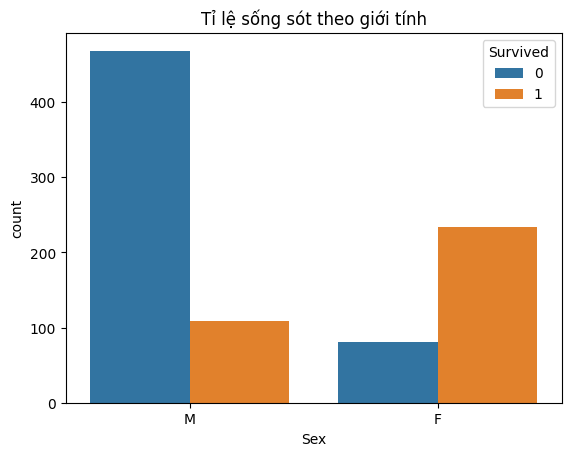

Sex  Survived
F    1           233
     0            81
M    0           468
     1           109
Name: count, dtype: int64


In [27]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Tỉ lệ sống sót theo giới tính")
plt.show()

print(df.groupby('Sex')['Survived'].value_counts())


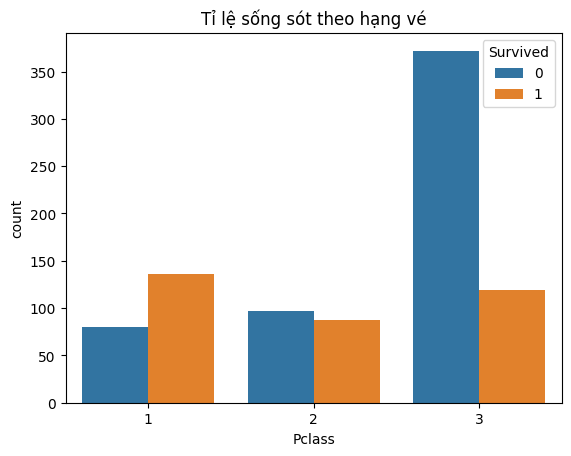

Pclass  Survived
1       1           136
        0            80
2       0            97
        1            87
3       0           372
        1           119
Name: count, dtype: int64


In [28]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Tỉ lệ sống sót theo hạng vé")
plt.show()

print(df.groupby('Pclass')['Survived'].value_counts())


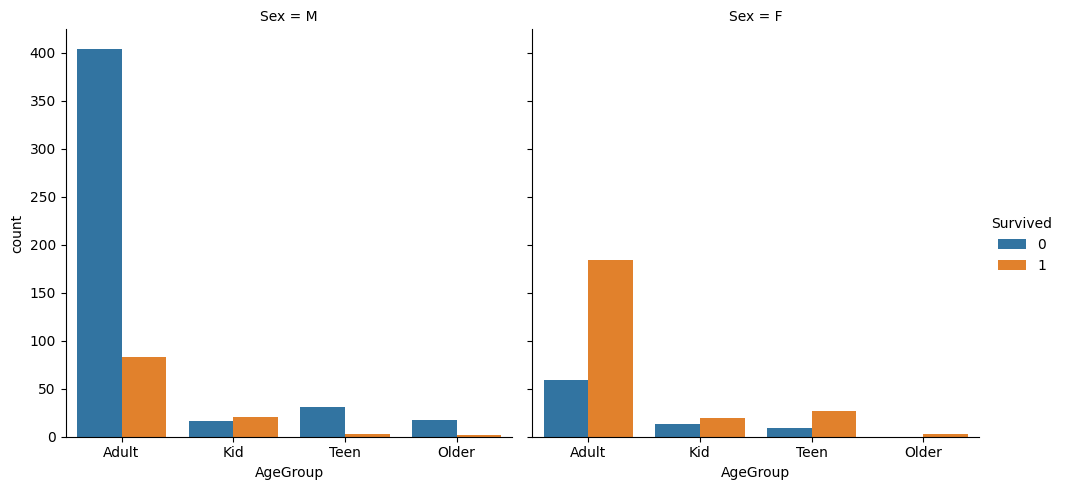

Sex  AgeGroup  Survived
F    Adult     1           184
               0            59
     Kid       1            19
               0            13
     Older     1             3
     Teen      1            27
               0             9
M    Adult     0           404
               1            83
     Kid       1            21
               0            16
     Older     0            17
               1             2
     Teen      0            31
               1             3
Name: count, dtype: int64


In [29]:
sns.catplot(x='AgeGroup', hue='Survived', col='Sex', kind='count', data=df)
plt.show()

print(df.groupby(['Sex','AgeGroup'])['Survived'].value_counts())


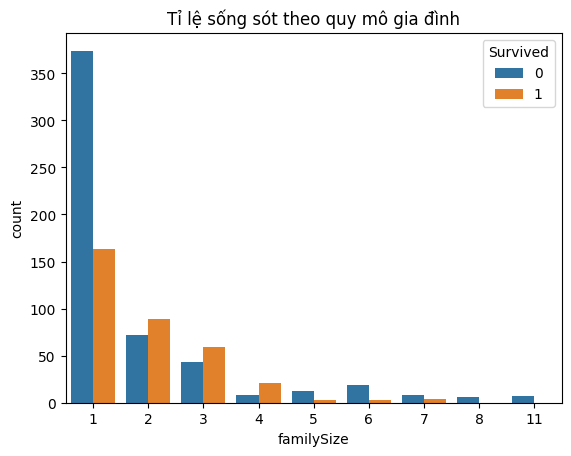

familySize  Survived
1           0           374
            1           163
2           1            89
            0            72
3           1            59
            0            43
4           1            21
            0             8
5           0            12
            1             3
6           0            19
            1             3
7           0             8
            1             4
8           0             6
11          0             7
Name: count, dtype: int64


In [30]:
sns.countplot(x='familySize', hue='Survived', data=df)
plt.title("Tỉ lệ sống sót theo quy mô gia đình")
plt.show()

print(df.groupby('familySize')['Survived'].value_counts())


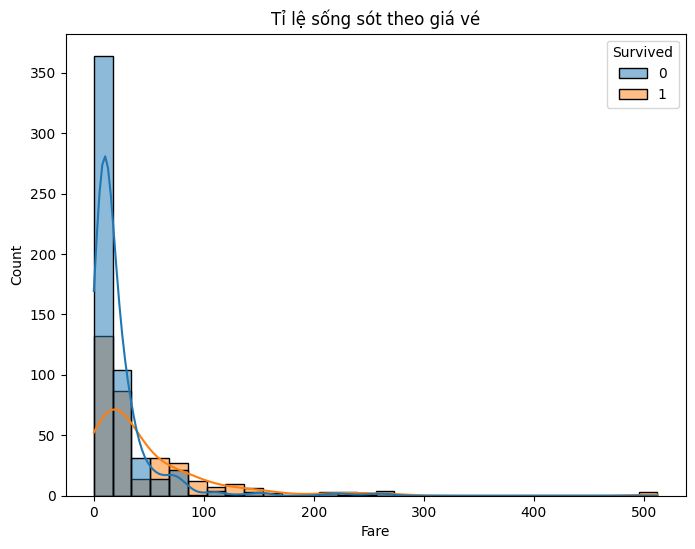

       Fare  Survived
0    7.2500         0
1   71.2833         1
2    7.9250         1
3   53.1000         1
4    8.0500         0
5    8.4583         0
6   51.8625         0
7   21.0750         0
8   11.1333         1
9   30.0708         1
10  16.7000         1
11  26.5500         1
12   8.0500         0
13  31.2750         0
14   7.8542         0
15  16.0000         1
16  29.1250         0
17  13.0000         1
18  18.0000         0
19   7.2250         1


In [31]:
plt.figure(figsize=(8,6))
sns.histplot(df, x='Fare', hue='Survived', bins=30, kde=True)
plt.title("Tỉ lệ sống sót theo giá vé")
plt.show()

print(df[['Fare','Survived']].head(20))


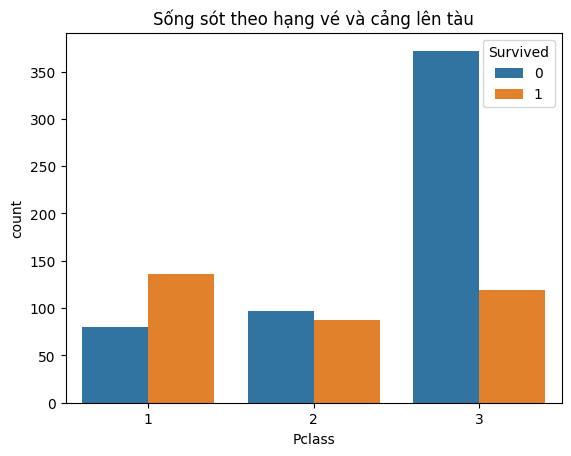

Pclass  Embarked  Survived
1       C         1            59
                  0            26
        Q         0             1
                  1             1
        S         1            74
                  0            53
2       C         1             9
                  0             8
        Q         1             2
                  0             1
        S         0            88
                  1            76
3       C         0            41
                  1            25
        Q         0            45
                  1            27
        S         0           286
                  1            67
Name: count, dtype: int64


In [32]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Sống sót theo hạng vé và cảng lên tàu")
plt.show()

print(df.groupby(['Pclass','Embarked'])['Survived'].value_counts())
